C:\Users\user\AppData\Roaming\Python\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")



=== XGBoost Feature Importance (all features) ===
                Feature  Importance
12      US_FedFundsRate    0.070071
0              Debt_GDP    0.067588
13     World_GDP_growth    0.065145
4    GDP_per_capita_USD    0.061733
6        fiscal_balance    0.058546
5             Inflation    0.058040
1           ExtDebt_GDP    0.057297
9       Reserves_months    0.056758
8    CurrentAccount_GDP    0.056606
2         DebtServ_XGDP    0.052996
10  ExchangeRate_change    0.052372
7       primary_balance    0.052089
11       Trade_openness    0.051661
16       ICRG_political    0.051616
3        RealGDP_growth    0.050948
15                  VIX    0.049703
14      Oil_price_index    0.045679
17         ElectionYear    0.041151


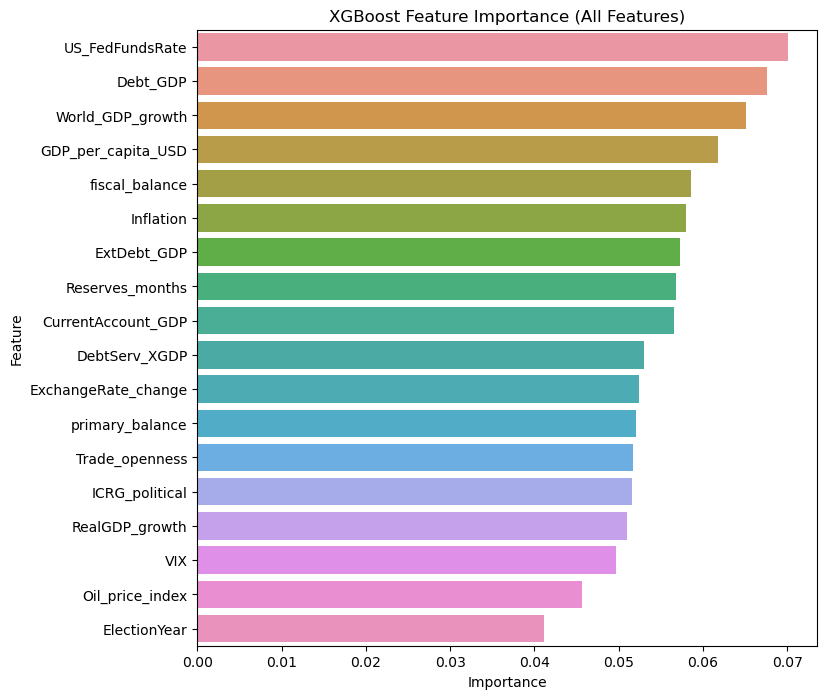

In [3]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load dataset
df = pd.read_csv('sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv')

# 2️⃣ Define all features (except Country and Year)
all_features = [
    'Debt_GDP', 'ExtDebt_GDP', 'DebtServ_XGDP', 'RealGDP_growth', 'GDP_per_capita_USD',
    'Inflation', 'fiscal_balance', 'primary_balance', 'CurrentAccount_GDP', 'Reserves_months',
    'ExchangeRate_change', 'Trade_openness', 'US_FedFundsRate', 'World_GDP_growth',
    'Oil_price_index', 'VIX', 'ICRG_political', 'ElectionYear'
]

X = df[all_features]
y = df['Default']

# 3️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4️⃣ Train XGBoost model
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

# 5️⃣ Extract feature importance
importance = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\n=== XGBoost Feature Importance (all features) ===")
print(importance_df)

# 6️⃣ Plot feature importance
plt.figure(figsize=(8,8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('XGBoost Feature Importance (All Features)')
plt.show()



=== Summary statistics by Default class ===
          Debt_GDP                       ExtDebt_GDP                        \
              mean     median        std        mean     median        std   
Default                                                                      
0        84.199036  83.344496  37.318435   53.952280  53.475962  25.763509   
1        85.475183  89.991347  38.119323   51.164416  51.009474  24.145513   

        DebtServ_XGDP                       RealGDP_growth  ...  \
                 mean     median        std           mean  ...   
Default                                                     ...   
0           22.672418  22.588537  10.095150       -0.04779  ...   
1           21.920363  20.787663  10.090426        0.03437  ...   

        Oil_price_index        VIX                       ICRG_political  \
                    std       mean     median        std           mean   
Default                                                                   
0  

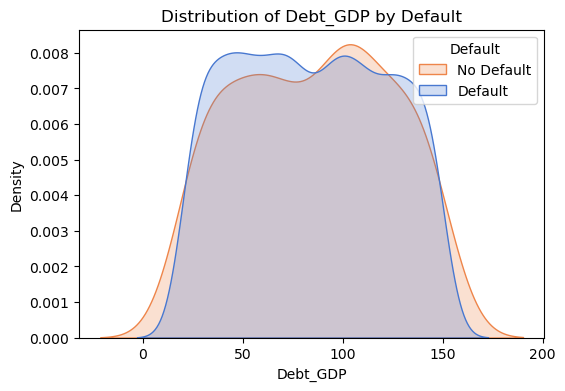

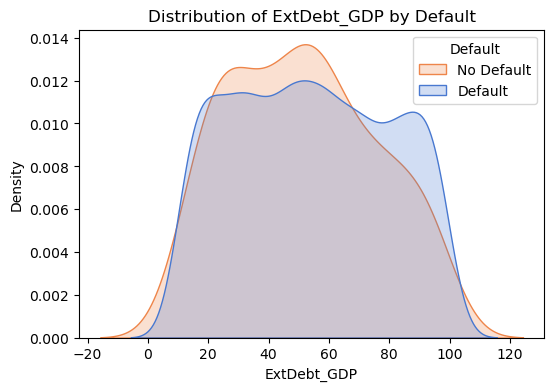

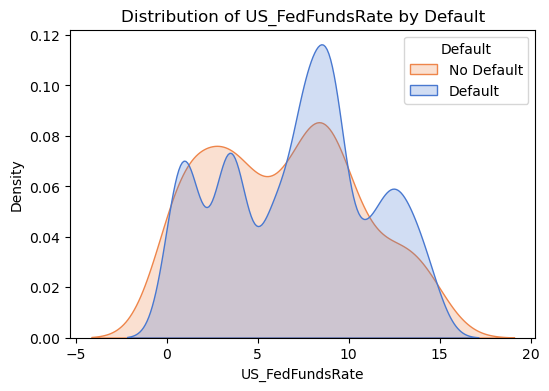

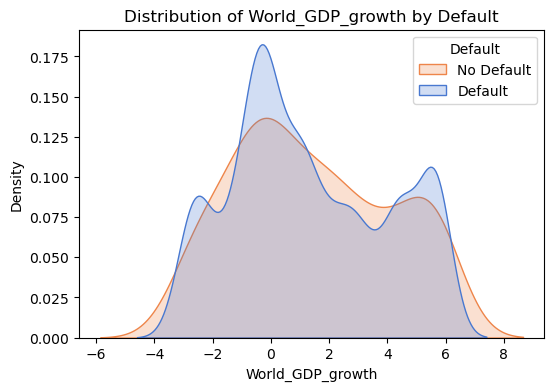

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load dataset
df = pd.read_csv('sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv')

# 2️⃣ Define numeric feature columns (exclude 'Country', 'Year', 'Default')
numeric_features = [
    'Debt_GDP', 'ExtDebt_GDP', 'DebtServ_XGDP', 'RealGDP_growth', 'GDP_per_capita_USD',
    'Inflation', 'fiscal_balance', 'primary_balance', 'CurrentAccount_GDP', 'Reserves_months',
    'ExchangeRate_change', 'Trade_openness', 'US_FedFundsRate', 'World_GDP_growth',
    'Oil_price_index', 'VIX', 'ICRG_political', 'ElectionYear'
]

# 3️⃣ Summary stats by class
summary_by_class = df.groupby('Default')[numeric_features].agg(['mean', 'median', 'std'])

print("\n=== Summary statistics by Default class ===")
print(summary_by_class)

# 4️⃣ Class distribution
class_counts = df['Default'].value_counts()
class_distribution = class_counts / len(df)

print("\n=== Class distribution for Default ===")
print(class_counts.rename('Count'))
print(class_distribution.rename('Proportion'))

# 5️⃣ Plots: Distribution plot for selected key features
key_features = ['Debt_GDP', 'ExtDebt_GDP', 'US_FedFundsRate', 'World_GDP_growth']

for feature in key_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=feature, hue='Default', common_norm=False, fill=True, palette='muted')
    plt.title(f'Distribution of {feature} by Default')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend(title='Default', labels=['No Default', 'Default'])
    plt.show()



Accuracy: 0.065, F1 Score: 0.105
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       569
           1       0.06      1.00      0.10        33

    accuracy                           0.06       602
   macro avg       0.53      0.51      0.06       602
weighted avg       0.95      0.06      0.03       602


=== Logistic Regression Coefficients ===
             Feature  Coefficient
1   World_GDP_growth     0.027606
5     RealGDP_growth     0.005372
4     ICRG_political     0.005117
10         Inflation     0.003595
2    Oil_price_index     0.000632
8        ExtDebt_GDP    -0.002796
9     Trade_openness    -0.002902
7                VIX    -0.003138
3     fiscal_balance    -0.010442
11     DebtServ_XGDP    -0.010998
6    US_FedFundsRate    -0.036935
0       ElectionYear    -0.093110


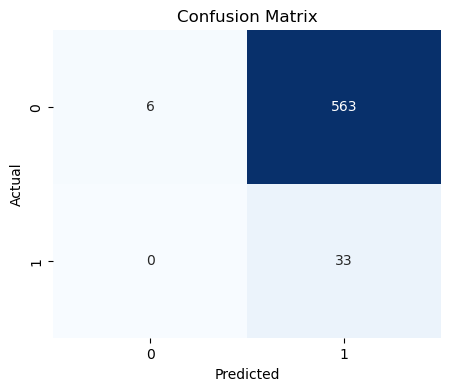

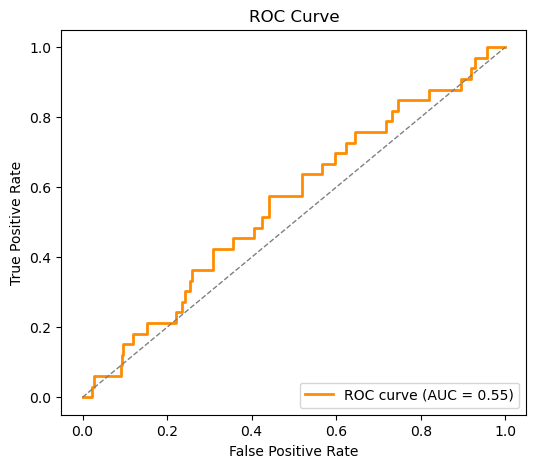

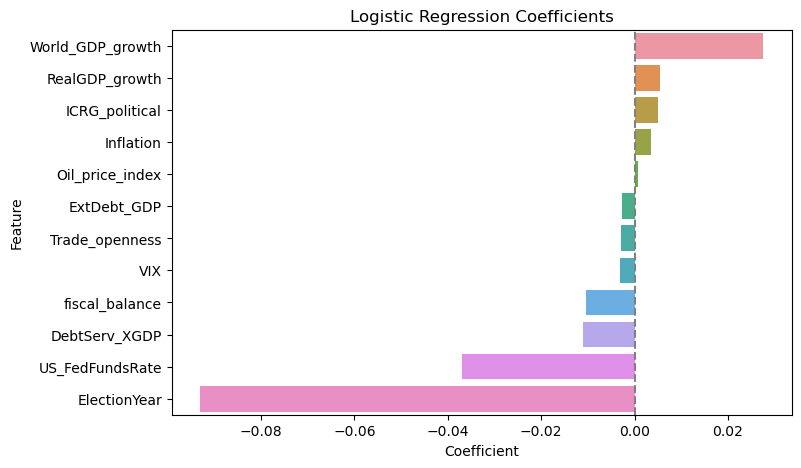

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load dataset
df = pd.read_csv('sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv')

# 2️⃣ Define selected top 12 features
selected_features = [
    'ElectionYear',
    'World_GDP_growth',
    'Oil_price_index',
    'fiscal_balance',
    'ICRG_political',
    'RealGDP_growth',
    'US_FedFundsRate',
    'VIX',
    'ExtDebt_GDP',
    'Trade_openness',
    'Inflation',
    'DebtServ_XGDP'
]

X = df[selected_features]
y = df['Default']

# 3️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4️⃣ Logistic Regression with class weighting for imbalance
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 5️⃣ Predictions and evaluation
y_prob = model.predict_proba(X_test)[:, 1]
threshold = 0.3  # Adjust threshold like before
y_pred = (y_prob >= threshold).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.3f}, F1 Score: {f1:.3f}")
print(classification_report(y_test, y_pred))

# 6️⃣ Coefficients table (feature importance for logistic regression)
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\n=== Logistic Regression Coefficients ===")
print(coef_df)

# 7️⃣ Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 8️⃣ ROC Curve plot
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# 9️⃣ Coefficient bar plot
plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Logistic Regression Coefficients')
plt.axvline(0, color='gray', linestyle='--')
plt.show()


In [ ]:
#with k fold


--- Fold 1 ---
Accuracy: 0.058, F1 Score: 0.104
              precision    recall  f1-score   support

           0       1.00      0.00      0.01       569
           1       0.06      1.00      0.10        33

    accuracy                           0.06       602
   macro avg       0.53      0.50      0.06       602
weighted avg       0.95      0.06      0.01       602


--- Fold 2 ---
Accuracy: 0.056, F1 Score: 0.104
              precision    recall  f1-score   support

           0       1.00      0.00      0.00       569
           1       0.05      1.00      0.10        33

    accuracy                           0.06       602
   macro avg       0.53      0.50      0.05       602
weighted avg       0.95      0.06      0.01       602


--- Fold 3 ---
Accuracy: 0.056, F1 Score: 0.104
              precision    recall  f1-score   support

           0       1.00      0.00      0.00       569
           1       0.05      1.00      0.10        33

    accuracy                       

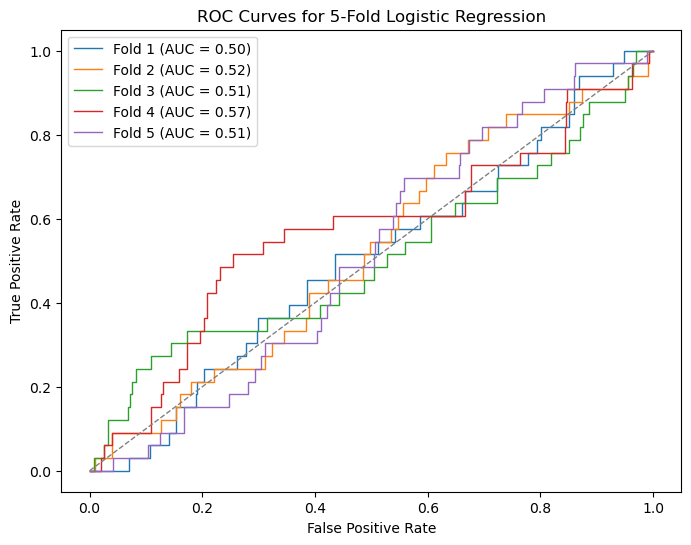

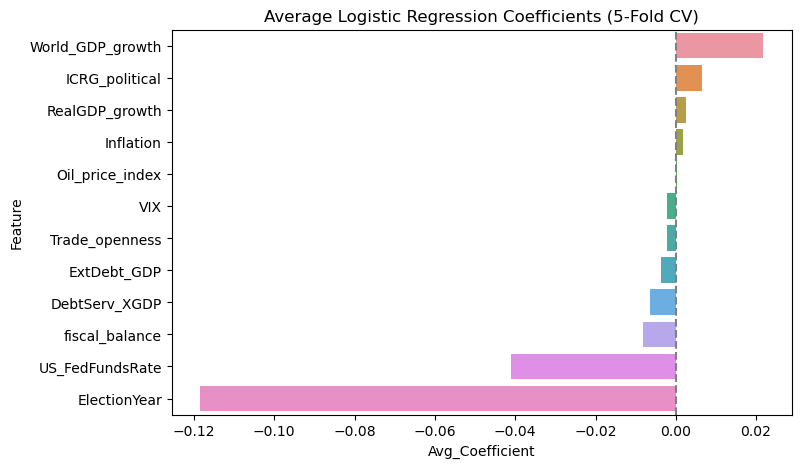

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load dataset
df = pd.read_csv('sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv')

# 2️⃣ Define selected top 12 features
selected_features = [
    'ElectionYear',
    'World_GDP_growth',
    'Oil_price_index',
    'fiscal_balance',
    'ICRG_political',
    'RealGDP_growth',
    'US_FedFundsRate',
    'VIX',
    'ExtDebt_GDP',
    'Trade_openness',
    'Inflation',
    'DebtServ_XGDP'
]

X = df[selected_features]
y = df['Default']

# 3️⃣ Define K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
f1_scores = []
coef_accumulator = np.zeros(len(selected_features))
roc_auc_scores = []

plt.figure(figsize=(8,6))
for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    print(f"\n--- Fold {fold} ---")
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # 4️⃣ Logistic Regression with class weighting
    model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    # 5️⃣ Predict probabilities + threshold adjustment
    y_prob = model.predict_proba(X_test)[:, 1]
    threshold = 0.3
    y_pred = (y_prob >= threshold).astype(int)
    
    # 6️⃣ Metrics for this fold
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracies.append(acc)
    f1_scores.append(f1)
    
    print(f"Accuracy: {acc:.3f}, F1 Score: {f1:.3f}")
    print(classification_report(y_test, y_pred))
    
    # 7️⃣ Coefficient accumulation
    coef_accumulator += model.coef_[0]
    
    # 8️⃣ ROC curve for this fold
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, label=f"Fold {fold} (AUC = {roc_auc:.2f})")

# 9️⃣ Average coefficients across folds
avg_coefs = coef_accumulator / kf.get_n_splits()
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Avg_Coefficient': avg_coefs
}).sort_values(by='Avg_Coefficient', ascending=False)

# 🔟 Cross-validation summary
print("\n=== Cross-validation summary ===")
print(f"Mean Accuracy: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Mean F1 Score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"Mean AUC: {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")

print("\n=== Average Logistic Regression Coefficients ===")
print(coef_df)

# 🔹 Plot mean ROC curves
plt.plot([0,1], [0,1], linestyle='--', color='gray', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for 5-Fold Logistic Regression")
plt.legend()
plt.show()

# 🔹 Coefficient bar plot
plt.figure(figsize=(8,5))
sns.barplot(x='Avg_Coefficient', y='Feature', data=coef_df)
plt.title('Average Logistic Regression Coefficients (5-Fold CV)')
plt.axvline(0, color='gray', linestyle='--')
plt.show()


In [5]:
import pandas as pd
import statsmodels.api as sm

# 1️⃣ Load dataset
df = pd.read_csv('sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv')

# 2️⃣ Define predictors (you can adjust this to use all or selected features)
features = [
    'Debt_GDP', 'ExtDebt_GDP', 'DebtServ_XGDP', 'RealGDP_growth', 'GDP_per_capita_USD',
    'Inflation', 'fiscal_balance', 'primary_balance', 'CurrentAccount_GDP', 'Reserves_months',
    'ExchangeRate_change', 'Trade_openness', 'US_FedFundsRate', 'World_GDP_growth',
    'Oil_price_index', 'VIX', 'ICRG_political', 'ElectionYear'
]

X = df[features]
y = df['Default']

# 3️⃣ Add constant for intercept
X = sm.add_constant(X)

# 4️⃣ Fit Probit model
probit_model = sm.Probit(y, X).fit()

# 5️⃣ Display summary
print("\n=== Probit Regression Summary ===")
print(probit_model.summary())

# 6️⃣ Optional: Get predicted probabilities
df['Probit_Predicted_Prob'] = probit_model.predict(X)


Optimization terminated successfully.
         Current function value: 0.209173
         Iterations 6

=== Probit Regression Summary ===
                          Probit Regression Results                           
Dep. Variable:                Default   No. Observations:                 3010
Model:                         Probit   Df Residuals:                     2991
Method:                           MLE   Df Model:                           18
Date:                Wed, 16 Jul 2025   Pseudo R-squ.:                 0.01548
Time:                        20:59:52   Log-Likelihood:                -629.61
converged:                       True   LL-Null:                       -639.51
Covariance Type:            nonrobust   LLR p-value:                    0.3442
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.2791      0.291     -4.399   

In [6]:
import pandas as pd
import statsmodels.api as sm

# 1️⃣ Load dataset
df = pd.read_csv('sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv')

# 2️⃣ Define 8 most important features based on your XGBoost results:
top_8_features = [
    'US_FedFundsRate',
    'Debt_GDP',
    'World_GDP_growth',
    'GDP_per_capita_USD',
    'fiscal_balance',
    'Inflation',
    'ExtDebt_GDP',
    'Reserves_months'
]

X = df[top_8_features]
y = df['Default']

# 3️⃣ Add constant for intercept
X = sm.add_constant(X)

# 4️⃣ Fit Probit model
probit_model = sm.Probit(y, X).fit()

# 5️⃣ Display summary
print("\n=== Probit Regression Summary (Top 8 Features) ===")
print(probit_model.summary())

# 6️⃣ Optional: predicted probabilities
df['Probit_Predicted_Prob'] = probit_model.predict(X)


Optimization terminated successfully.
         Current function value: 0.210766
         Iterations 6

=== Probit Regression Summary (Top 8 Features) ===
                          Probit Regression Results                           
Dep. Variable:                Default   No. Observations:                 3010
Model:                         Probit   Df Residuals:                     3001
Method:                           MLE   Df Model:                            8
Date:                Wed, 16 Jul 2025   Pseudo R-squ.:                0.007982
Time:                        21:05:22   Log-Likelihood:                -634.41
converged:                       True   LL-Null:                       -639.51
Covariance Type:            nonrobust   LLR p-value:                    0.2506
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.3151      0.181

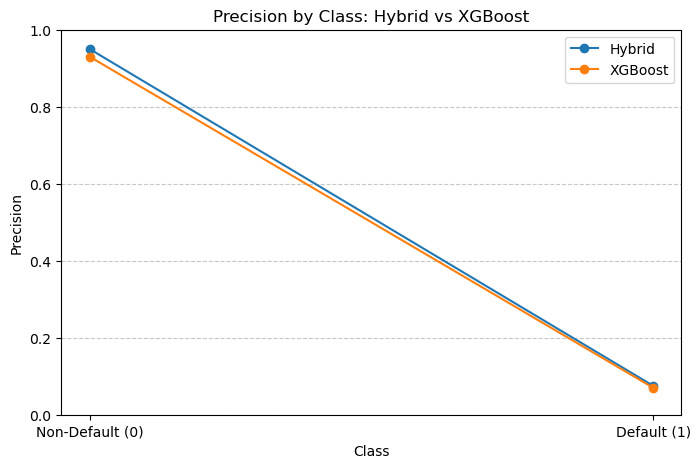

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Precision values from your models
data = {
    'Model': ['Hybrid', 'Hybrid', 'XGBoost', 'XGBoost'],
    'Class': ['Non-Default (0)', 'Default (1)', 'Non-Default (0)', 'Default (1)'],
    'Precision': [0.95, 0.075, 0.93, 0.07]
}

df_prec = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
for model in df_prec['Model'].unique():
    subset = df_prec[df_prec['Model'] == model]
    plt.plot(subset['Class'], subset['Precision'], marker='o', label=model)

plt.ylim(0, 1)
plt.title('Precision by Class: Hybrid vs XGBoost')
plt.xlabel('Class')
plt.ylabel('Precision')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [9]:
pip install shap


Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for shap from https://files.pythonhosted.org/packages/aa/7c/eead607a358b2466b95b302e4a7eae717eeed53615653fbbd4c1527041b9/shap-0.48.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for slicer==0.0.8 from https://files.pythonhosted.org/packages/63/81/9ef641ff4e12cbcca30e54e72fb0951a2ba195d0cda0ba4100e532d929db/slicer-0.0.8-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/544.4 kB ? eta -:--:--
    --------------------------------------- 10.2/544.4 kB ? eta -:--:--
   -- ------------------------------------ 41.0/544.4 kB 653.6 kB/s eta 0:00:01
   ---------- ----------------------------- 143.4/544.4 kB 1.4 MB/s eta 0:00:01
   ----------------- ---------------------- 235.5/544.4 kB 1.8 MB/s eta 0:00:01
   --------------------------- ------------ 368.6/544.4 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 544.4/54

In [1]:
import pandas as pd
import statsmodels.api as sm
import shap
import numpy as np

# 1️⃣ Load dataset
df = pd.read_csv("sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv")

# 2️⃣ Define predictors
features = [
    'Debt_GDP', 'ExtDebt_GDP', 'DebtServ_XGDP', 'RealGDP_growth', 'GDP_per_capita_USD',
    'Inflation', 'fiscal_balance', 'primary_balance', 'CurrentAccount_GDP', 'Reserves_months',
    'ExchangeRate_change', 'Trade_openness', 'US_FedFundsRate', 'World_GDP_growth',
    'Oil_price_index', 'VIX', 'ICRG_political', 'ElectionYear'
]

X = df[features]
y = df['Default']

# 3️⃣ Add constant
X = sm.add_constant(X)

# 4️⃣ Fit Probit model
probit_model = sm.Probit(y, X).fit()

# 5️⃣ Get coefficients as a surrogate explanation (SHAP for linear models)
coefs = probit_model.params.values
X_array = X.values

# 6️⃣ SHAP LinearExplainer approximation
explainer = shap.LinearExplainer(probit_model, X_array)
shap_values = explainer.shap_values(X_array)

# 7️⃣ Visualize SHAP summary
shap.summary_plot(shap_values, features=X.columns)


Optimization terminated successfully.
         Current function value: 0.209173
         Iterations 6


InvalidModelError: An unknown model type was passed: <class 'statsmodels.discrete.discrete_model.BinaryResultsWrapper'>